In [1]:
"""Hydrangea demo: session EDA, then state-fitting EDA.

Runs from the notebook. `# %%` marks each cell boundary — split there.

The package root is discovered by walking up from the working directory, so
this works whether the notebook is launched from the repo root or from
Hydrangea_demo/, locally or on the cloud box where the repo lives at
/notebooks/CumulantDynamicsGuiltByAssociation. The data mount defaults to
/storage/dandi_downloads and can be overridden with HYDRANGEA_DATA_DIR.

Cells:
    1. setup: paths, imports, constants
    2. navigate the dataset with pynapple's Folder API
    3. load one session, build the analysis epoch
    4. derive behaviour the archive does not ship (running speed)
    5. build the analysis object with its metadata tables
    6. register behaviour channels
    7. spiking + behaviour EDA          <- judge epoch / unit sample / channels
    8. normalize + normalization report <- judge bin size and normalization
    9. global embedding
   10. folds + state fitting + HMM report
   11. save, reload, summarize
"""

# %% ==========================================================================
# CELL 1 — setup
# =============================================================================

import os
import re
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import pynapple as nap


def find_package_root(start):
    """Walk up from `start` looking for the hybrid_dynamics_core package."""
    start = Path(start).resolve()
    for candidate in (start, *start.parents):
        if (candidate / "hybrid_dynamics_core").is_dir():
            return candidate
        nested = candidate / "Hydrangea_demo"
        if (nested / "hybrid_dynamics_core").is_dir():
            return nested
    return start


PACKAGE_ROOT = find_package_root(Path.cwd())
if str(PACKAGE_ROOT) not in sys.path:
    sys.path.insert(0, str(PACKAGE_ROOT))

from hybrid_dynamics_core.base import HybridDynamicsAnalysis  # noqa: E402
from hybrid_dynamics_core.spiking_and_behaviour_eda import (  # noqa: E402
    compute_speed_from_position,
)

DOWNLOAD_DIR = Path(os.environ.get("HYDRANGEA_DATA_DIR", "/storage/dandi_downloads")).resolve()
MODEL_DIR = DOWNLOAD_DIR / "hydrangea_models"
DANDISET_ID = "001695"
VERSION_ID = "0.260319.2023"

# Session to analyze. Set either to None to take the first behaviour recording.
SUBJECT = "M01"
SESSION = "20240313T100000"

BIN_SIZE_S = 0.050
EDA_WINDOW_S = 60
N_UNITS_PER_GROUP = 5

if DOWNLOAD_DIR.is_dir():
    MODEL_DIR.mkdir(parents=True, exist_ok=True)
print("Package root:", PACKAGE_ROOT)
print("Download dir:", DOWNLOAD_DIR)


Package root: /notebooks/CumulantDynamicsGuiltByAssociation/Hydrangea_demo
Download dir: /storage/dandi_downloads


In [2]:


# %% ==========================================================================
# CELL 2 — navigate the dataset
# =============================================================================
# pynapple's Folder API walks the subject/session tree and prints the whole
# hierarchy, so the inventory only has to parse identifiers out of the
# BIDS-style filenames:
#     sub-M01_ses-20240313T100000_behavior+ecephys.nwb
#     ^^^^^^^ ^^^^^^^^^^^^^^^^^^^ ^^^^^^^^^^^^^^^^^^
#     subject session             modalities

project = nap.load_folder(str(DOWNLOAD_DIR))
project.view


def parse_session_name(nwb_path):
    """Subject, session, date, time, and modalities from an NWB filename."""
    nwb_path = Path(nwb_path)
    stem = nwb_path.stem

    subject = re.search(r"(?:^|_)sub-([^_]+)", stem)
    session = re.search(r"(?:^|_)ses-([^_]+)", stem)
    subject = subject.group(1) if subject else nwb_path.parent.name.replace("sub-", "")
    session = session.group(1) if session else "unknown"

    date, time = None, None
    if "T" in session:
        raw_date, raw_time = session.split("T", 1)
        if len(raw_date) == 8 and raw_date.isdigit():
            date = f"{raw_date[:4]}-{raw_date[4:6]}-{raw_date[6:]}"
        if len(raw_time) >= 6 and raw_time[:6].isdigit():
            time = f"{raw_time[:2]}:{raw_time[2:4]}:{raw_time[4:6]}"

    modalities = stem.split("_")[-1].split("+")
    return {
        "subject": subject,
        "session": session,
        "date": date,
        "time": time,
        "modalities": "+".join(modalities),
        "has_behavior": "behavior" in modalities,
        "size_mb": round(nwb_path.stat().st_size / 1e6, 1),
        "nwb_file": str(nwb_path),
    }


def session_inventory(root):
    """Table of every NWB recording under the data mount."""
    rows = [parse_session_name(p) for p in sorted(Path(root).rglob("*.nwb"))]
    if not rows:
        return pd.DataFrame()
    return pd.DataFrame(rows).sort_values(["subject", "session"]).reset_index(drop=True)


inventory = session_inventory(DOWNLOAD_DIR)
print(f"\n{len(inventory)} recordings, {inventory['subject'].nunique()} subjects")
print(inventory.to_string(index=False))



📂 dandi_downloads
├── 📂 hydrangea_models
├── 📂 sub-M01
│   ├── sub-M01_ses-20240312T100000_behavior+ecephys    |        NWB file
│   ├── sub-M01_ses-20240313T100000_behavior+ecephys    |        NWB file
│   ├── sub-M01_ses-20240308T100000_ecephys     |        NWB file
│   ├── sub-M01_ses-20240318T100000_behavior+ecephys    |        NWB file
│   └── sub-M01_ses-20240314T100000_behavior+ecephys    |        NWB file
├── 📂 sub-M02
│   ├── sub-M02_ses-20240318T100000_behavior+ecephys    |        NWB file
│   ├── sub-M02_ses-20240312T100000_behavior+ecephys    |        NWB file
│   ├── sub-M02_ses-20240314T100000_behavior+ecephys    |        NWB file
│   └── sub-M02_ses-20240313T100000_behavior+ecephys    |        NWB file
├── 📂 sub-M03
│   ├── sub-M03_ses-20240621T100000_behavior+ecephys    |        NWB file
│   ├── sub-M03_ses-20240623T100000_behavior+ecephys    |        NWB file
│   ├── sub-M03_ses-20240624T100000_behavior+ecephys    |        NWB file
│   └── sub-M03_ses-20240622T100000_behavior+ecephys    |        NWB file
└── 📂 sub-M05
    ├── sub-M05_ses-20240730T100000_behavior+ecephys    |        NWB file
    ├── sub-M05_ses-20240729T100000_behavior+ecephys    |        NWB file
    └── sub-M05_ses-20240731T100000_behavior+ecephys    |        NWB file


16 recordings, 4 subjects
subject         session       date     time       modalities  has_behavior  size_mb                                                                          nwb_file
    M01 20240308T100000 2024-03-08 10:00:00          ecephys         False     70.7          /storage/dandi_downloads/sub-M01/sub-M01_ses-20240308T100000_ecephys.nwb
    M01 20240312T100000 2024-03-12 10:00:00 behavior+ecephys          True    187.4 /storage/dandi_downloads/sub-M01/sub-M01_ses-20240312T100000_behavior+ecephys.nwb
    M01 20240313T100000 2024-03-13 10:00:00 behavior+ecephys          True    125.8 /storage/dandi_downloads/sub-M01/sub-M01_ses-20240313T100000_behavior+ecephys.nwb
    M01 20240314T100000 2024-03-14 10:00:00 behavior+ecephys          True    134.6 /storage/dandi_downloads/sub-M01/sub-M01_ses-20240314T100000_behavior+ecephys.nwb
    M01 20240318T100000 2024-03-18 10:00:00 behavior+ecephys          True    190.0 /storage/dandi_downloads/sub-M01/sub-M01_ses-20240318T10000

In [3]:

# %% ==========================================================================
# CELL 3 — load one session and build the analysis epoch
# =============================================================================

candidates = inventory[inventory["has_behavior"]]
if SUBJECT is not None:
    candidates = candidates[candidates["subject"] == SUBJECT]
if SESSION is not None:
    candidates = candidates[candidates["session"] == SESSION]
if len(candidates) == 0:
    raise FileNotFoundError(f"No behaviour recording for subject={SUBJECT}, session={SESSION}")

session_nwb_path = Path(candidates.iloc[0]["nwb_file"]).resolve()
session_nwb = nap.load_file(str(session_nwb_path))
print("Session NWB path:", session_nwb_path)
print("NWB keys:", list(session_nwb.keys()))

spike_group = session_nwb["units"]
position_xy = session_nwb["Position"]

# The maze epoch is the span over which position was tracked. Spiking outside it
# is unusable for behaviour-linked state analysis, so the whole pipeline is
# restricted to it.
maze_start = float(position_xy.index[0])
maze_end = float(position_xy.index[-1])
maze_ep = nap.IntervalSet(start=maze_start, end=maze_end)
spike_group_maze = spike_group.restrict(maze_ep)

print(f"Maze epoch: {maze_start:.1f}s to {maze_end:.1f}s ({maze_end - maze_start:.1f}s)")
print("Units before/after maze restriction:", len(spike_group), "/", len(spike_group_maze))


Session NWB path: /storage/dandi_downloads/sub-M01/sub-M01_ses-20240313T100000_behavior+ecephys.nwb
NWB keys: ['units', 'SleepStates', 'Best_Ripple_channel_LFP_CA1', 'Speed', 'Position']
Maze epoch: 4892.8s to 6521.2s (1628.3s)
Units before/after maze restriction: 240 / 240


In [4]:
# %% ==========================================================================
# CELL 4 — derive behaviour the archive does not ship
# =============================================================================
# Running speed is not in the downloaded NWB, so it is computed here rather than
# inside the analysis object: how a derived behavioural channel is built is a
# per-dataset decision.

speed_t, speed_vals = compute_speed_from_position(
    position_xy, columns=("x", "y"), smooth_window_s=0.25
)
print(f"Derived running speed: {len(speed_t)} samples, median {np.median(speed_vals):.3f} units/s")



Derived running speed: 40708 samples, median 1.193 units/s


In [5]:
# %% ==========================================================================
# CELL 5 — build the analysis object with its metadata tables
# =============================================================================
# Unit metadata (region, cell type, anything else on the TsGroup) is read off
# the spike group automatically and carried through unit filtering. Trial,
# condition, and region tables are optional and dataset-specific.

trials = None
try:
    trials = session_nwb["trials"]
except Exception:
    print("No trials table in this NWB.")

hybdyn = HybridDynamicsAnalysis(
    spike_group=spike_group_maze,
    bin_size_s=BIN_SIZE_S,
    maze_epoch=maze_ep,
    trial_table=trials,  # an IntervalSet is coerced to a start/end table
    session_id=session_nwb_path.stem,
    mouse_id=candidates.iloc[0]["subject"],
    embedding_method="pca",
    state_discovery_method="gaussian_hmm",
    random_state=0,
    report="selected",
)



No trials table in this NWB.


In [6]:

# %% ==========================================================================
# CELL 6 — register behaviour channels
# =============================================================================
# Continuous channels carry a sampling-rate descriptor (inferred from the
# timestamps here). Discrete channels carry a time interval and optional
# subtypes. Both project onto the spike-matrix bins later.

hybdyn.add_continuous_behavior(
    "position",
    time=position_xy.index.values,
    values=np.column_stack([position_xy["x"].values, position_xy["y"].values]),
    columns=["x", "y"],
    units="cm",
    description="tracked position on the maze",
)

hybdyn.add_continuous_behavior(
    "running_speed",
    time=speed_t,
    values=speed_vals,
    units="cm/s",
    color="k",
    description="derived from position, 0.25s boxcar",
)

hybdyn.add_events_from_interval_set(
    "maze_epoch",
    maze_ep,
    description="position-tracked span used for all fitting",
)

if trials is not None:
    hybdyn.add_events_from_interval_set("trials", trials, description="task trials")



Metadata tables
------------------------------------
unit_metadata    rows=240    cols=14  rate, cell_type, cell_area, firing_rate, ab_ratio, burstIndex_Mizuseki2012, cv2, maxWaveformCh, troughToPeak, acg_tau_decay, acg_tau_rise, thetaModulationIndex, x_position_probe, y_position_probe
trial_table      rows=0      cols=0   -
condition_table  rows=0      cols=0   -
region_table     rows=0      cols=0   -
region column:    cell_area
cell-type column: cell_type

Unit counts (region x cell_type, with Total):
cell_type  Total  Narrow Interneuron  Pyramidal Cell  Wide Interneuron
region                                                                
CA1          103                  15              85                 3
CA3           83                  55              27                 1
RSC           54                  23              15                16


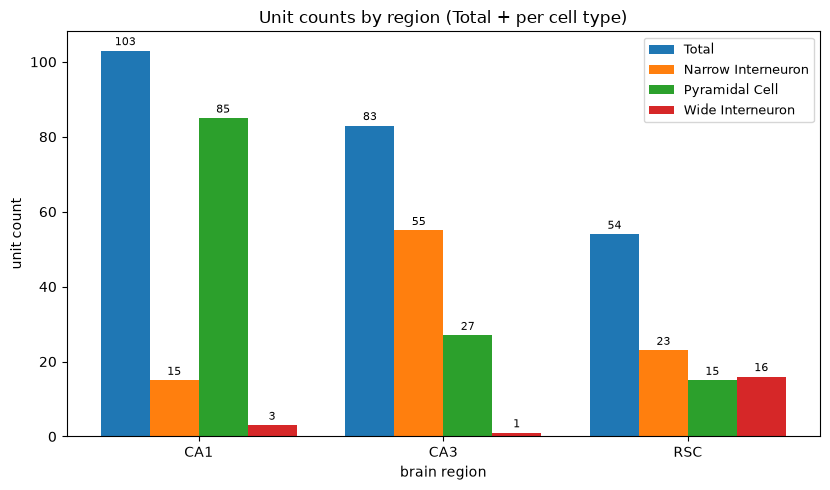


Registered behaviour channels:
                     kind  n_dims  n_samples_or_events  sampling_rate_hz  \
name                                                                       
position       continuous       2                40708         25.018764   
running_speed  continuous       1                40708         25.018764   
maze_epoch       discrete       1                    1               NaN   

               t_start_s      t_end_s subtypes units  \
name                                                   
position       4892.8469  6521.175133     None    cm   
running_speed  4892.8469  6521.175133     None  cm/s   
maze_epoch     4892.8469  6521.175133     None     s   

                                              description  
name                                                       
position                     tracked position on the maze  
running_speed         derived from position, 0.25s boxcar  
maze_epoch     position-tracked span used for all fitting  


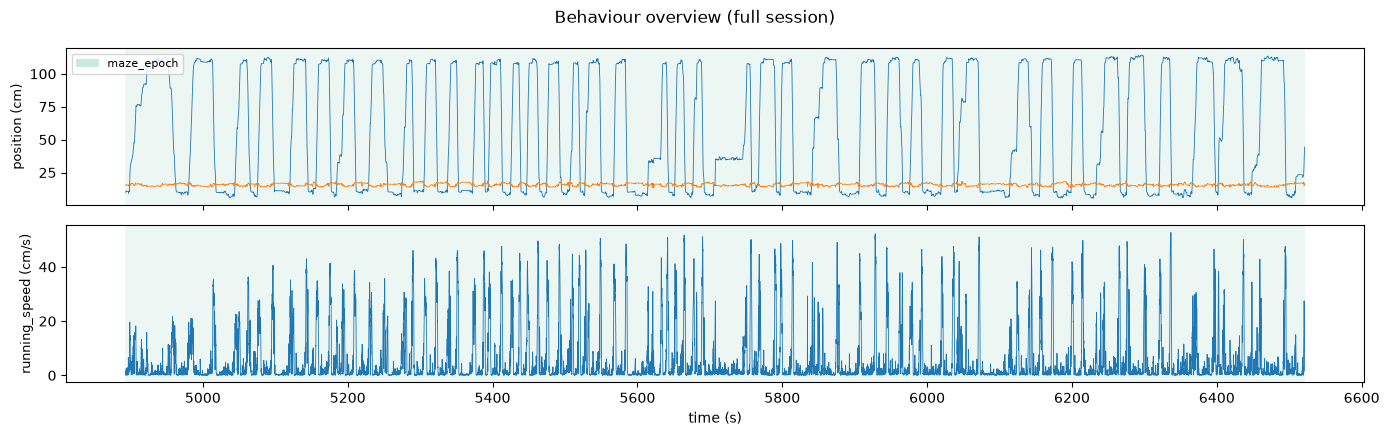

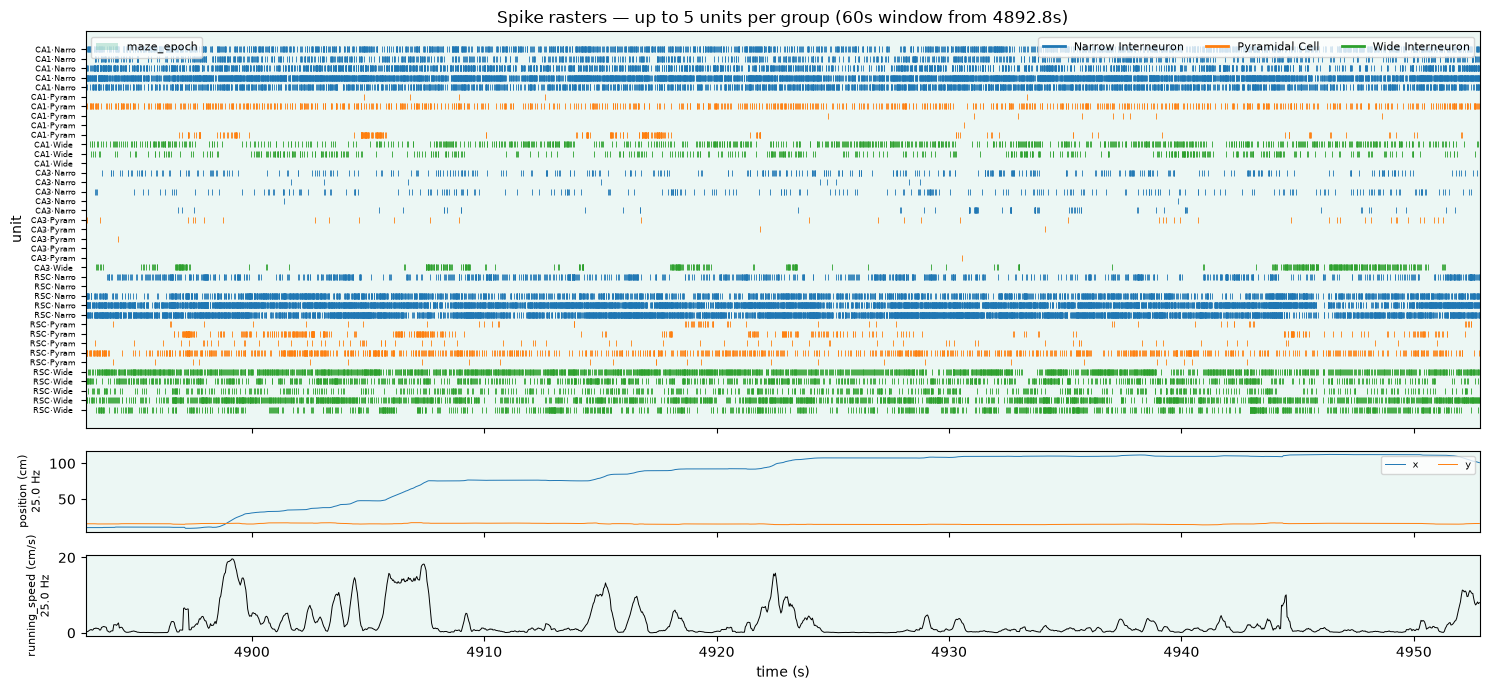

In [7]:

# %% ==========================================================================
# CELL 7 — spiking + behaviour EDA
# =============================================================================
# Human judgement: are the epoch, the unit sample, and the behavioural channels
# sensible before anything is binned?
#
# Prints the metadata inventory and the region x cell-type unit counts, then
# plots the unit inventory, the full-session behaviour overview, and spike
# rasters over the behavioural traces.

hybdyn.spiking_behavior_report(
    window_s=EDA_WINDOW_S,
    n_units_per_group=N_UNITS_PER_GROUP,
    show=True,
)


/notebooks/CumulantDynamicsGuiltByAssociation/Hydrangea_demo/hybrid_dynamics_core/normalization.py:82: UserWarning: Dropped 3 neurons with no spikes in analyzed time interval. Per-region dropped counts -> CA1:1, CA3:2.
  warnings.warn(msg)


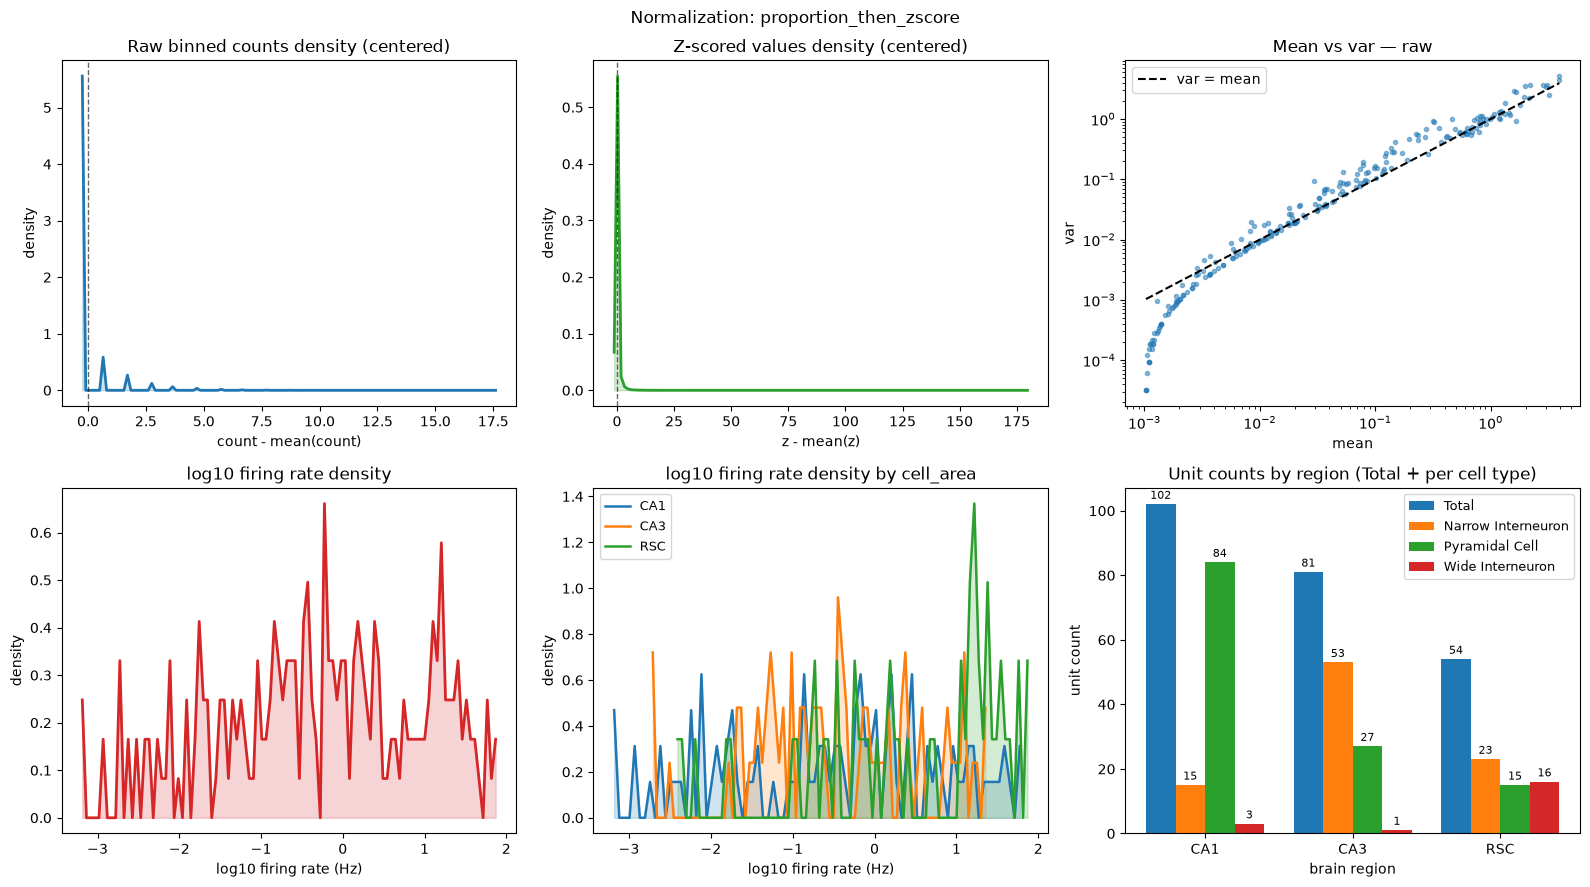

Observation matrix: (32567, 237) (bins x units)


In [8]:
# %% ==========================================================================
# CELL 8 — normalization
# =============================================================================
# Human judgement: is the binning and normalization method appropriate for this
# firing-rate distribution?

hybdyn.normalize(method="proportion_zscore", zscore=True, restrict_to_epoch=True)
hybdyn.normalization_report(show=True)
print("Observation matrix:", hybdyn.spike_matrix.shape, "(bins x units)")



In [9]:

# %% ==========================================================================
# CELL 9 — behaviour on the observation bins
# =============================================================================
# Behaviour projected onto the same bins as the observation matrix. This is the
# table that pairs with state_labels_ once the HMM has run.

behavior_bins = hybdyn.align_behavior_to_bins()
print("Behaviour aligned to bins:", behavior_bins.shape)
print(behavior_bins.head())


Behaviour aligned to bins: (32567, 5)
                     x          y  running_speed  maze_epoch.occupancy  \
bin_start_s                                                              
4892.847567  10.203952  15.577299       0.317052                   1.0   
4892.897567  10.203952  15.589111       0.321706                   1.0   
4892.947567  10.203952  15.647082       0.460283                   1.0   
4892.997567  10.202825  15.647082       0.666163                   1.0   
4893.047567  10.144302  15.647082       0.845899                   1.0   

             maze_epoch.count  
bin_start_s                    
4892.847567               1.0  
4892.897567               0.0  
4892.947567               0.0  
4892.997567               0.0  
4893.047567               0.0  


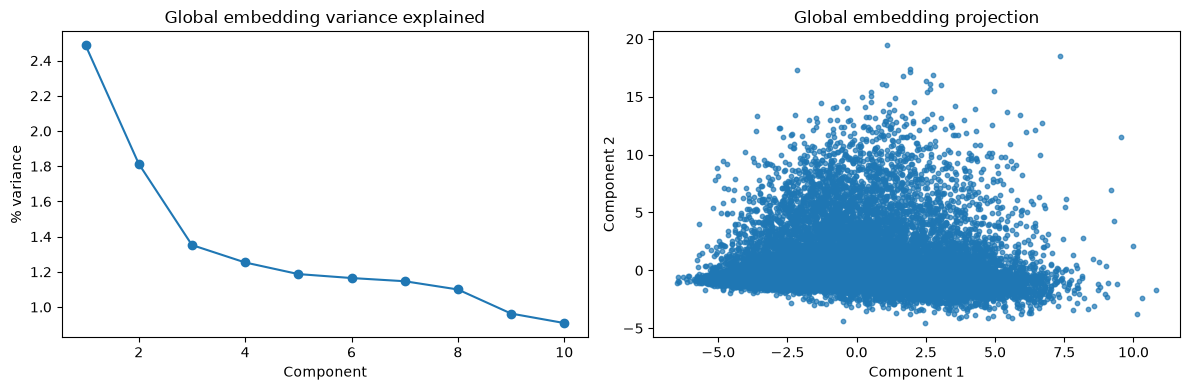

In [10]:


# %% ==========================================================================
# CELL 10 — global embedding
# =============================================================================

hybdyn.global_embedding(method="pca", n_components=10, whiten=False, standardize=True)
hybdyn.report_embeddings(show=True)


In [11]:
# %% ==========================================================================
# CELL 11 — folds and state fitting
# =============================================================================

hybdyn.build_folds(
    k_fold=5,
    fold_strategy="temporal_segments",
    shuffle_within_segments=True,
    seed=0,
)

hybdyn.fit_states(
    n_states_min=2,
    n_states_max=10,
    k_fold=5,
    fold_strategy="temporal_segments",
    shuffle_within_segments=True,
    n_iter=100,
    covariance_type="diag",
    verbose=True,
    use_cv=True,
    report="selected",
)


# %% ==========================================================================
# CELL 12 — HMM report
# =============================================================================
# Human judgement: inspect the ranked CV scores and choose a working K.

hybdyn.hmm_report(report="selected")
# hybdyn.hmm_report(report="full")


KeyboardInterrupt: 

In [ ]:

# Optional next step: local embedding inside one discovered state.
# hybdyn.local_embedding(state_labels=hybdyn.state_labels_, state_value=0, method="pca", label="state_0")
# hybdyn.report_embeddings(scope="local", label="state_0", show=True)


# %% ==========================================================================
# CELL 13 — save, reload, summarize
# =============================================================================

saved_model_path = MODEL_DIR / f"{session_nwb_path.stem}_best_hmm.pkl"
hybdyn.save_hmm_model(saved_model_path)
reloaded_artifact = hybdyn.load_hmm_model(saved_model_path)

print("Saved model path:", saved_model_path)
print("Reloaded model states:", reloaded_artifact["n_states"])
print("Best K:", hybdyn.best_k)
print("Model count:", len(hybdyn.hmm_models))

hybdyn.describe(as_text=True)
